In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

In [32]:
pd.read_json("docker_stats_log_streaming.jsonl", lines=True).head()

,timestamp_utc,container
0,2025-10-24 23:53:35.444130+00:00,"{'BlockIO': '0B / 0B', 'CPUPerc': '0.00%', 'Co..."
1,2025-10-24 23:53:35.444301+00:00,"{'BlockIO': '0B / 0B', 'CPUPerc': '0.01%', 'Co..."
2,2025-10-24 23:53:35.444366+00:00,"{'BlockIO': '98.3kB / 221kB', 'CPUPerc': '0.00..."
3,2025-10-24 23:53:35.444404+00:00,"{'BlockIO': '303kB / 0B', 'CPUPerc': '0.00%', ..."
4,2025-10-24 23:53:35.444436+00:00,"{'BlockIO': '0B / 0B', 'CPUPerc': '0.22%', 'Co..."


In [23]:
df = pd.read_json("docker_stats_log_streaming.jsonl", lines=True)

df_stats_achatados = pd.json_normalize(df['container'])
df_final = pd.concat([df['timestamp_utc'], df_stats_achatados], axis=1)
df_final['timestamp_utc'] = pd.to_datetime(df_final['timestamp_utc'])

df_final[df_final["Name"] == 'processing'][['timestamp_utc', 'CPUPerc']].sort_values(by='timestamp_utc', ascending=True)

,timestamp_utc,CPUPerc
0,2025-10-24 23:53:35.444130+00:00,0.00%
5,2025-10-24 23:53:35.444465+00:00,0.00%
10,2025-10-24 23:53:35.944038+00:00,0.00%
15,2025-10-24 23:53:35.944330+00:00,0.00%
20,2025-10-24 23:53:36.443824+00:00,0.00%
...,...,...
1425,2025-10-24 23:54:46.445273+00:00,5.33%
1430,2025-10-24 23:54:46.944280+00:00,13.46%
1435,2025-10-24 23:54:46.944630+00:00,13.46%
1440,2025-10-24 23:54:47.444403+00:00,13.46%


Iniciando carregamento dos cenários...
Processando: '1 Motor' (Arquivo: 1_motors_docker_stats_log_streaming.jsonl)
Processando: '2 Motores' (Arquivo: 2_motors_docker_stats_log_streaming.jsonl)
Processando: '3 Motores' (Arquivo: 3_motors_docker_stats_log_streaming.jsonl)
Dados carregados. Gerando gráfico comparativo...
Gráfico salvo com sucesso em: comparativo_desempenho_carga.png


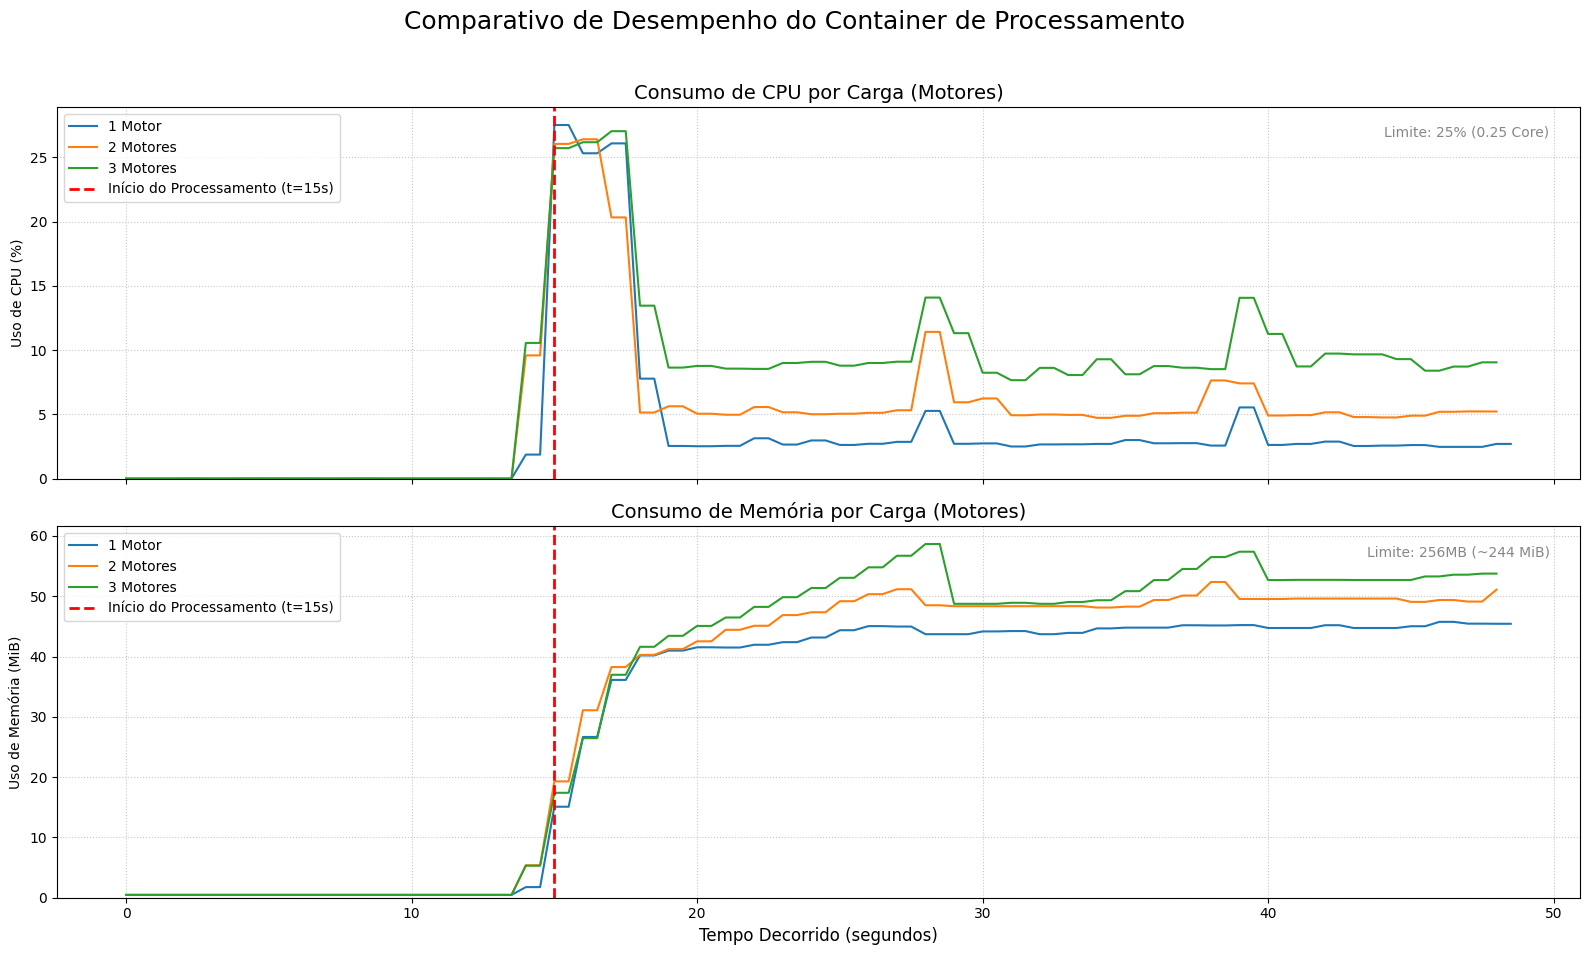

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import sys
from typing import Dict, List, Optional

def parse_mem_usage_to_mib(mem_string: str) -> Optional[float]:
    """
    Converte a string de 'MemUsage' (ex: "19.57MiB / 15.35GiB")
    para um valor float em MebiBytes (MiB).
    """
    try:
        usage_part = mem_string.split(' / ')[0].strip()
        match = re.match(r"([\d\.]+)([a-zA-Z]+)", usage_part)
        if not match:
            return None

        value = float(match.group(1))
        unit = match.group(2).lower()

        if unit == 'gib':
            return value * 1024
        elif unit == 'mib':
            return value
        elif unit == 'kib':
            return value / 1024
        elif unit == 'b':
            return value / (1024 * 1024)
        else:
            return value

    except Exception:
        return None

def carregar_e_processar_log(filepath: str, container_name: str) -> Optional[pd.DataFrame]:
    """
    Carrega um arquivo .jsonl, filtra por um container, limpa os dados
    e calcula o tempo decorrido (começando do 0).
    """
    try:
        df_bruto = pd.read_json(filepath, lines=True)
        if df_bruto.empty:
            print(f"Aviso: O arquivo '{filepath}' está vazio.", file=sys.stderr)
            return None

        # Achatando a coluna 'container'
        df_stats = pd.json_normalize(df_bruto['container'])
        df_full = pd.concat([df_bruto['timestamp_utc'], df_stats], axis=1)
        df_full['timestamp_utc'] = pd.to_datetime(df_full['timestamp_utc'])

        # --- Filtragem e Processamento ---

        # 1. Filtrar pelo container desejado
        df_container = df_full[df_full['Name'] == container_name].copy()
        if df_container.empty:
            print(f"Erro: Nenhum dado para o container '{container_name}' no arquivo '{filepath}'.", file=sys.stderr)
            print(f"Nomes disponíveis: {df_full['Name'].unique()}")
            return None

        # 2. Calcular tempo decorrido (relativo ao início DESTE log)
        t_start = df_container['timestamp_utc'].min()
        df_container['elapsed_seconds'] = (df_container['timestamp_utc'] - t_start).dt.total_seconds()

        # 3. Limpar CPU
        df_container['cpu_perc_num'] = df_container['CPUPerc'].str.replace('%', '').astype(float)

        # 4. Limpar Memória
        df_container['mem_mib_num'] = df_container['MemUsage'].apply(parse_mem_usage_to_mib)

        return df_container

    except FileNotFoundError:
        print(f"Erro: Arquivo não encontrado em '{filepath}'", file=sys.stderr)
        return None
    except Exception as e:
        print(f"Erro ao processar o arquivo '{filepath}': {e}", file=sys.stderr)
        return None

def plotar_metricas_comparativas(scenarios_data: Dict[str, pd.DataFrame], output_filename: str):
    """
    Plota a comparação de CPU e Memória para múltiplos cenários (ex: 1 motor vs 2 motores).
    """
    if not scenarios_data:
        print("Nenhum dado válido para plotar.", file=sys.stderr)
        return

    # Define estilos de linha para diferenciar as curvas
    styles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]

    # --- 1. Criar a Figura e os Subplots ---
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Comparativo de Desempenho do Container de Processamento', fontsize=18)

    ax_cpu, ax_mem = axes[0], axes[1]

    # --- 2. Iterar e Plotar (Subplot de CPU) ---
    ax_cpu.set_title('Consumo de CPU por Carga (Motores)', fontsize=14)
    ax_cpu.set_ylabel('Uso de CPU (%)')

    for i, (scenario_name, df) in enumerate(scenarios_data.items()):
        style = "-" #styles[i % len(styles)]
        ax_cpu.plot(
            df['elapsed_seconds'],
            df['cpu_perc_num'],
            label=scenario_name, # Ex: "1 Motor"
            linewidth=1.5,
            linestyle=style
        )

    ax_cpu.axvline(
        x=15,
        color='red',
        linestyle='--',
        linewidth=2,
        label='Início do Processamento (t=15s)'
    )

    # Anotação de limite de CPU
    ax_cpu.text(0.98, 0.95, "Limite: 25% (0.25 Core)",
                transform=ax_cpu.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right',
                color='dimgray', alpha=0.8)

    ax_cpu.legend(loc='upper left')
    ax_cpu.grid(True, linestyle=':', alpha=0.7)
    ax_cpu.set_ylim(bottom=0)

    # --- 3. Iterar e Plotar (Subplot de Memória) ---
    ax_mem.set_title('Consumo de Memória por Carga (Motores)', fontsize=14)
    ax_mem.set_ylabel('Uso de Memória (MiB)')

    for i, (scenario_name, df) in enumerate(scenarios_data.items()):
        style = "-" #styles[i % len(styles)]
        ax_mem.plot(
            df['elapsed_seconds'],
            df['mem_mib_num'],
            label=scenario_name, # Ex: "1 Motor"
            linewidth=1.5,
            linestyle=style
        )

    # Anotação de limite de Memória
    mem_limit_mib = (256 * 10**6) / (2**20) # ~244.14 MiB

    ax_mem.axvline(
        x=15,
        color='red',
        linestyle='--',
        linewidth=2,
        label='Início do Processamento (t=15s)'
    )
    ax_mem.text(0.98, 0.95, f"Limite: 256MB (~{mem_limit_mib:.0f} MiB)",
                transform=ax_mem.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right',
                color='dimgray', alpha=0.8)

    ax_mem.legend(loc='upper left')
    ax_mem.grid(True, linestyle=':', alpha=0.7)
    ax_mem.set_ylim(bottom=0)

    # --- 4. Finalizar e Salvar ---
    ax_mem.set_xlabel('Tempo Decorrido (segundos)', fontsize=12)

    # Ajusta o layout para evitar sobreposição
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])

    try:
        plt.savefig(output_filename, dpi=150)
        print(f"Gráfico salvo com sucesso em: {output_filename}")
    except Exception as e:
        print(f"Erro ao salvar o gráfico: {e}", file=sys.stderr)

# --- PONTO DE ENTRADA DO SCRIPT ---
if __name__ == "__main__":
    NOME_CONTAINER_PROCESSAMENTO = "processing" # Exemplo, ajuste ao seu

    # 2. Mapeamento de Cenários para Arquivos de Log
    #    Adicione ou remova linhas aqui para comparar
    SCENARIOS_A_CARREGAR = {
        # "Nome da Legenda": "caminho/para/o/arquivo.jsonl"
        "1 Motor": "1_motors_docker_stats_log_streaming.jsonl",
        "2 Motores": "2_motors_docker_stats_log_streaming.jsonl",
        "3 Motores": "3_motors_docker_stats_log_streaming.jsonl",
        # "4 Motores": "docker_stats_4_motores.jsonl",
        # "5 Motores": "docker_stats_5_motores.jsonl",
    }

    # 3. Nome do arquivo de imagem que será gerado
    ARQUIVO_GRAFICO_SAIDA = "comparativo_desempenho_carga.png"
    # ----------------------

    scenarios_data_carregados = {}

    print("Iniciando carregamento dos cenários...")

    for nome_cenario, caminho_arquivo in SCENARIOS_A_CARREGAR.items():
        print(f"Processando: '{nome_cenario}' (Arquivo: {caminho_arquivo})")
        df_cenario = carregar_e_processar_log(caminho_arquivo, NOME_CONTAINER_PROCESSAMENTO)

        if df_cenario is not None:
            scenarios_data_carregados[nome_cenario] = df_cenario
        else:
            print(f"Falha ao carregar o cenário '{nome_cenario}'.")

    if scenarios_data_carregados:
        print("Dados carregados. Gerando gráfico comparativo...")
        plotar_metricas_comparativas(scenarios_data_carregados, ARQUIVO_GRAFICO_SAIDA)
    else:
        print("Nenhum dado foi carregado com sucesso. Verifique os caminhos e o nome do container.")
        sys.exit(1)